In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open("names.txt",'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
chars = sorted(list(set("".join(word for word in words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {s:i for i,s in stoi.items()}
vocab_size = len(itos)

In [4]:
block_size = 3 #context length. How many characters are used to predict the next one

def build_dataset(words):
    
    X, Y = [], [] #X input to NN, Y is label
    for w in words:
        #print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context),'---->', itos[ix])
            context = context[1:] + [ix] # sliding window

    X = torch.tensor(X)
    Y = torch.tensor(Y)    
    return X, Y


import random
random.seed(42)
random.shuffle(words)

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [5]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in,fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters 
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        # Running stats
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True, unbiased=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        # Update running stats
        if self.training:
            with torch.no_grad():
                self.running_mean = self.momentum * xmean + (1-self.momentum) * self.running_mean
                self.running_var = self.momentum * xvar + (1-self.momentum) * self.running_var

        return self.out


    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

In [123]:
n_embd = 10
n_hidden = 100
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size,n_embd), generator=g)
            
layers = [
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, vocab_size, bias=False), BatchNorm1d(vocab_size),
]

with torch.no_grad():
    # apply gain 
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

47024


In [7]:
max_steps = 200000
batch_size = 32
lossi = []
#ud = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function
  
  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
   # ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])
  #with torch.no_grad():

  if i >= 1000:
    break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000: 3.5210


layer 2 (      Tanh): mean -0.00, std 0.63, saturated: 2.53%
layer 5 (      Tanh): mean +0.00, std 0.64, saturated: 2.50%
layer 8 (      Tanh): mean -0.00, std 0.64, saturated: 2.50%
layer 11 (      Tanh): mean -0.00, std 0.64, saturated: 2.03%
layer 14 (      Tanh): mean +0.00, std 0.65, saturated: 1.56%


/var/folders/tl/916xhm_90fb33z8_y1k4pkxc0000gn/T/ipykernel_25202/2495111583.py:7: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:823.)
  print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))


Text(0.5, 1.0, 'activation distribution')

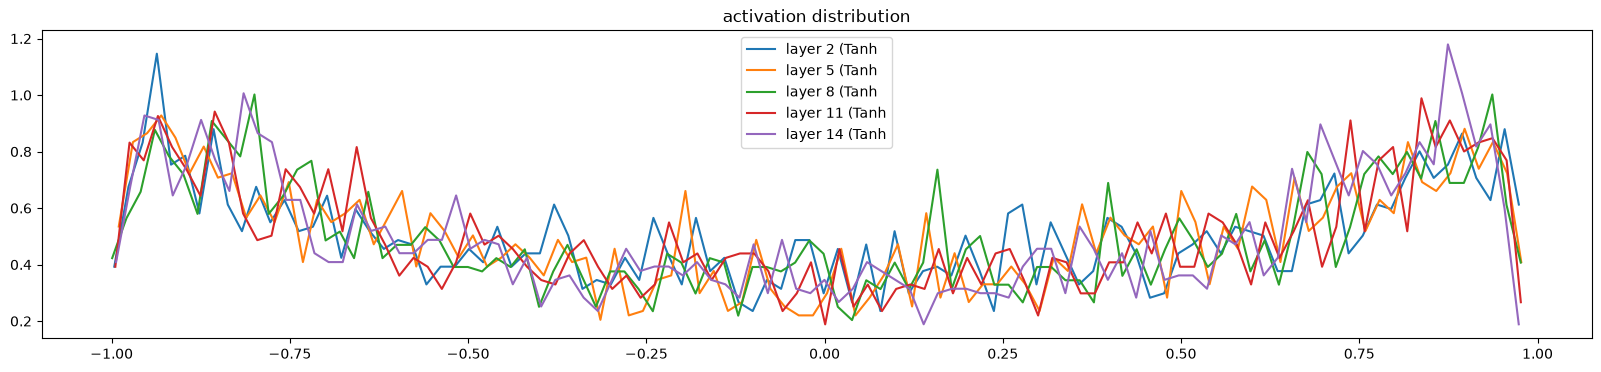

In [8]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

# Gain too big and we just saturate tanh leading to 0 gradients and dead neurons
# Gain too small and we just pass through the same values we inputted. Normal in => Normal out. Tanh(x) = x for small x

layer 2 (      Tanh): mean +0.000000, std 3.548422e-03
layer 5 (      Tanh): mean +0.000000, std 2.867568e-03
layer 8 (      Tanh): mean -0.000000, std 2.565280e-03
layer 11 (      Tanh): mean -0.000000, std 2.257973e-03
layer 14 (      Tanh): mean +0.000000, std 2.121371e-03


Text(0.5, 1.0, 'gradient distribution')

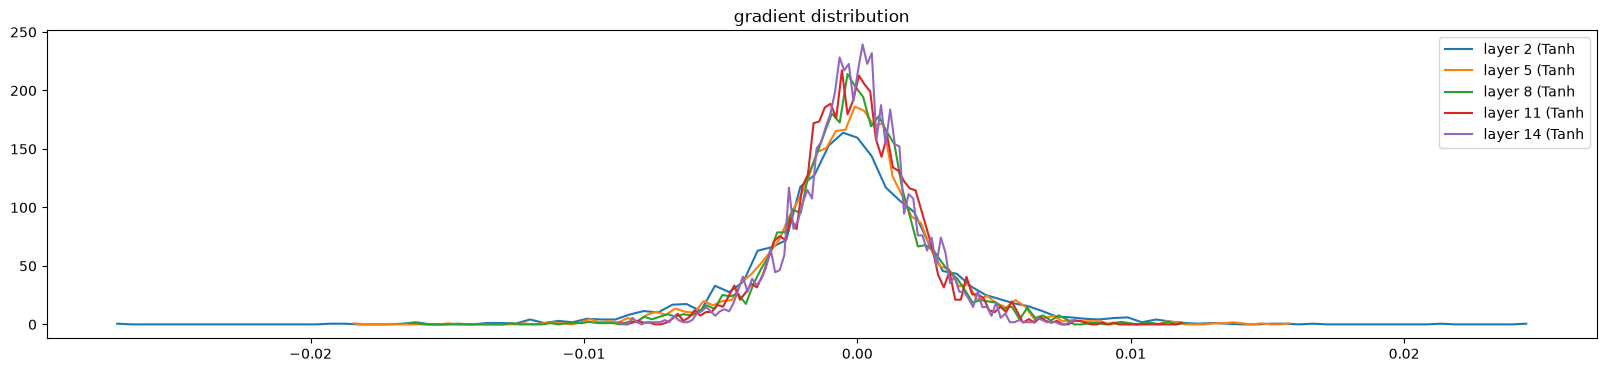

In [9]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

In [10]:
# E01 - Set all weights and biases to 0 initially

# the 27 end parameters train because we have the logits are all equal from the softmax. 

# But after this the gradients are all 0 so no further parameters ever get updated.

In [11]:
# E02 - Removing the batchNorm for inference after training

# W2 = W1 * gamma
# b2 = b1 + beta

In [162]:
n_embd = 10
n_hidden = 100
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size,n_embd), generator=g)
            
layers = [
  Linear(n_embd * block_size, n_hidden, bias=True), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=True), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, vocab_size, bias=True), BatchNorm1d(vocab_size),
]

with torch.no_grad():
    # apply gain 
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True

16651


In [180]:
# Normal fwd pass

# minibatch construct
ix = torch.tensor([10895, 11898, 21287,  6569, 21969,  2177,  2395,  1363, 15760, 15848,
        14663,  3298,  1361, 17396,  1514,  9763, 19022, 13875,  6111, 14349,
        15579, 18394, 16546, 16022, 18105,  1092, 22317, 18511, 11287,  9485,
         2398,  8732])
Xb, Yb = Xte[ix], Yte[ix] # batch X,Y

# forward pass
emb = C[Xb] # embed the characters into vectors
x = emb.view(emb.shape[0], -1) # concatenate the vectors
for layer in layers:
    x = layer(x)
loss = F.cross_entropy(x, Yb) # loss function
loss.item()

3.9474635124206543

In [182]:
emb = C[Xb] # embed the characters into vectors
x = emb.view(emb.shape[0], -1) # concatenate the vectors
for i,layer in enumerate(layers):
    if isinstance(layer, Linear):
        LinearLayer = layer
        BatchLayer = layers[i+1]

        W1 = LinearLayer.parameters()[0]
        b1 = LinearLayer.parameters()[1] if LinearLayer.bias is True else None

        W2 = BatchLayer.gamma * W1
        b2 = BatchLayer.beta + b1 if b1 else None

        x = x @ W2 + b2 if b2 else x @ W2
    else:
        x = layer(x)

loss = F.cross_entropy(x, Yb) # loss function
loss.item()

3.9474635124206543

In [141]:
len(layers)
for i, layer in enumerate(layers):
    print(i, layer)

0 <__main__.Linear object at 0x115a36830>
1 <__main__.BatchNorm1d object at 0x112e4c270>
2 <__main__.Tanh object at 0x115910dd0>
3 <__main__.Linear object at 0x115a35ff0>
4 <__main__.BatchNorm1d object at 0x11462c9e0>
5 <__main__.Tanh object at 0x115910cd0>
6 <__main__.Linear object at 0x115a35c80>
7 <__main__.BatchNorm1d object at 0x114a697b0>
